## 1. Environment Setup & Imports
Setting up the Python environment with necessary libraries for data manipulation, machine learning, and visualization.

### 1.1 Importing Data Manipulation Libraries

In [1]:
#import core data manipulation libraries
import pandas as pd
import numpy as np
import warnings
import os

#suppress warnings for cleaner notebook execution
warnings.filterwarnings('ignore')

### 1.2 Importing Machine Learning Libraries

In [2]:
#import scikit-learn preprocessing and metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance


#import algorithms
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.linear_model import LogisticRegression
import xgboost as xgb


#import imblearn for handling target imbalance
import imblearn
from imblearn.over_sampling import SMOTE

### 1.3 Importing Visualization Libraries

In [3]:
#import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

#set default plot style
sns.set_theme(style="whitegrid")

In [4]:
#Set project directories
BASE_DIR = os.path.abspath("..")   
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [5]:
final_hr_df = pd.read_csv(PROCESSED_DIR+'/final_hr_df.csv')

---
## 4. Model 1: Employee Attrition Prediction (Classification)
In this section, we build our first primary machine learning model. The goal is to predict which current employees are at a high risk of leaving the company (`Attrition_Target` = 1) based on their behavioral, financial, and demographic features.

### 4.1 Defining Features (X) and Target (y: Attrition_Target)
We separate our dataset into the target variable we want to predict and the feature matrix the model will learn from. We must also drop `Employee_ID` here, as identifiers hold no mathematical predictive value and will confuse the algorithms.

In [6]:
# Define the target variable
y = final_hr_df['Attrition_Target']

# Define the feature matrix by dropping the target and identifiers
X = final_hr_df.drop(columns=['Attrition_Target', 'Employee_ID'])

# Verify the shapes of X and y
print(f"Feature Matrix (X) Shape: {X.shape}")
print(f"Target Vector (y) Shape: {y.shape}")

Feature Matrix (X) Shape: (2000, 24)
Target Vector (y) Shape: (2000,)


### 4.2 Train-Test Split (80/20)
We split our data to evaluate model performance on unseen data. We allocate 80% of the data for training the model and 20% for testing. We use `stratify=y` to ensure both splits maintain the same ratio of attrited vs. active employees.

In [7]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensures target class proportions are preserved
)

#Display the dimensions of the split datasets
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (1600, 24)
Testing Features Shape: (400, 24)


### 4.3 Handling Target Imbalance using SMOTE
Real-world HR datasets are highly imbalanced (e.g., 85% stay, 15% leave). If left untreated, the model will just predict "Stay" for everyone and achieve artificial 85% accuracy. 

We use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic examples of the minority class (attrited employees) so the model learns their patterns equally. 

*Note: We apply SMOTE **only** to the training data. The testing data must remain untouched to simulate reality.*

In [8]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Compare class distributions before and after SMOTE
print("Target distribution BEFORE SMOTE (Training Set):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution AFTER SMOTE (Training Set):")
print(y_train_smote.value_counts(normalize=True) * 100)
print(f"\nNew Training Features Shape: {X_train_smote.shape}")

Target distribution BEFORE SMOTE (Training Set):
Attrition_Target
0    72.75
1    27.25
Name: proportion, dtype: float64

Target distribution AFTER SMOTE (Training Set):
Attrition_Target
0    50.0
1    50.0
Name: proportion, dtype: float64

New Training Features Shape: (2328, 24)


### 4.4 Training Random Forest Classifier
Random Forest is a powerful ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction. It is highly effective for tabular HR data as it handles non-linear relationships and interactions between variables well. We will train this model using our SMOTE-balanced training data.

In [9]:
# Initialize the Random Forest Classifier
# n_estimators=100 means we are building 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model on the balanced training data
rf_model.fit(X_train_smote, y_train_smote)

# Generate predictions on the untouched test set
rf_predictions = rf_model.predict(X_test)

print("Random Forest Classifier successfully trained!")

Random Forest Classifier successfully trained!


### 4.5 Training XGBoost Classifier
Extreme Gradient Boosting (XGBoost) is one of the most performant algorithms for structured data. Unlike Random Forest which builds trees independently, XGBoost builds trees sequentially, with each new tree correcting the errors of the previous ones. This often yields higher accuracy for complex classification tasks like attrition prediction.

In [10]:
# Initialize the XGBoost Classifier
# eval_metric='logloss' suppresses a common warning in newer xgboost versions
xgb_model = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

# Fit the model on the balanced training data
xgb_model.fit(X_train_smote, y_train_smote)

# Generate predictions on the untouched test set
xgb_predictions = xgb_model.predict(X_test)

print("XGBoost Classifier successfully trained!")

XGBoost Classifier successfully trained!


### 4.6 Model Evaluation & Comparison (Confusion Matrix, Precision, Recall, ROC-AUC)
Accuracy is a poor metric for imbalanced HR data. Instead, we evaluate our models using **Precision** (when we predict an employee will leave, how often are we right?) and **Recall** (out of all the employees who actually left, how many did we successfully catch?). We will also plot the Confusion Matrices and ROC-AUC curves to visually compare Random Forest and XGBoost.

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       291
           1       0.67      0.83      0.74       109

    accuracy                           0.84       400
   macro avg       0.80      0.84      0.81       400
weighted avg       0.86      0.84      0.85       400


--- XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       291
           1       0.67      0.80      0.73       109

    accuracy                           0.84       400
   macro avg       0.79      0.83      0.81       400
weighted avg       0.85      0.84      0.84       400



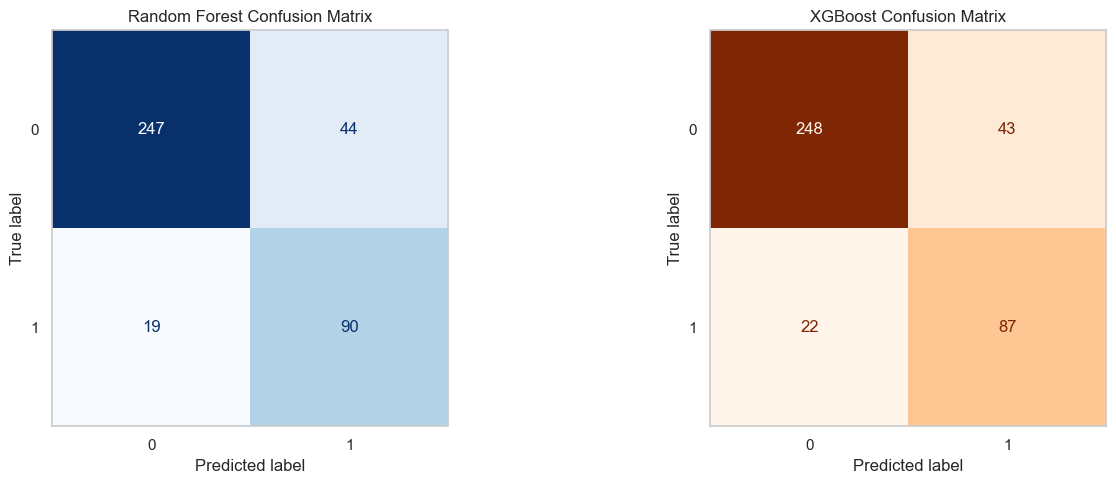

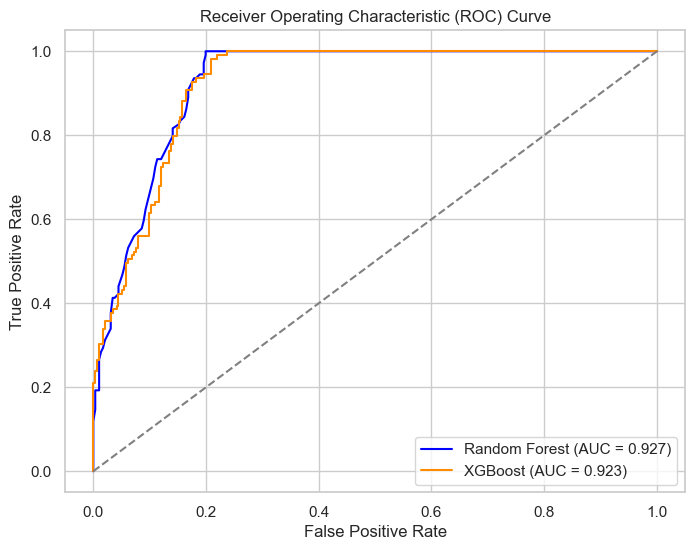

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Print textual classification reports
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_predictions))

print("\n--- XGBoost Performance ---")
print(classification_report(y_test, xgb_predictions))

# Set up the matplotlib figure for Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_predictions, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].grid(False) # Turn off grid lines for cleaner matrix

# Plot XGBoost Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, xgb_predictions, ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].grid(False)

plt.tight_layout()
plt.show()

# Calculate probabilities for ROC-AUC Curve
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate AUC scores
rf_auc = roc_auc_score(y_test, rf_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# Plot ROC Curves
plt.figure(figsize=(8, 6))
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color='blue')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Random guess line

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

### 4.7 Feature Importance Analysis (What drives attrition?)
A predictive model is only useful to HR if it is explainable. We need to tell the business *why* people are at risk. Here, we extract the feature importances from our best-performing model (typically XGBoost) to rank the top behavioral and demographic drivers of attrition.

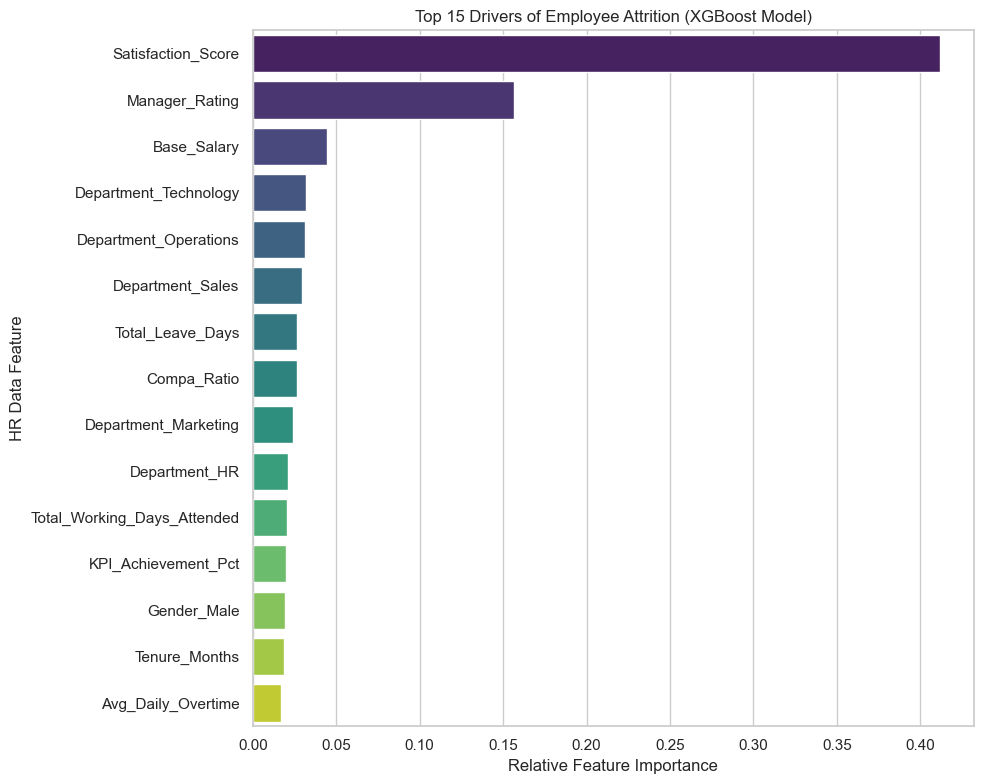

Top 5 Attrition Risk Factors Identified by AI:
- Satisfaction_Score (Weight: 0.4116)
- Manager_Rating (Weight: 0.1564)
- Base_Salary (Weight: 0.0442)
- Department_Technology (Weight: 0.0318)
- Department_Operations (Weight: 0.0313)


In [12]:
# Extract feature importances from the trained XGBoost model
importances = xgb_model.feature_importances_

# Create a DataFrame to hold feature names and their corresponding importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the Top 15 Drivers of Attrition
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(15), 
    palette='viridis'
)

plt.title('Top 15 Drivers of Employee Attrition (XGBoost Model)')
plt.xlabel('Relative Feature Importance')
plt.ylabel('HR Data Feature')
plt.tight_layout()
plt.show()

# Print the top 5 risk factors textually for the final report
print("Top 5 Attrition Risk Factors Identified by AI:")
for index, row in feature_importance_df.head(5).iterrows():
    print(f"- {row['Feature']} (Weight: {row['Importance']:.4f})")

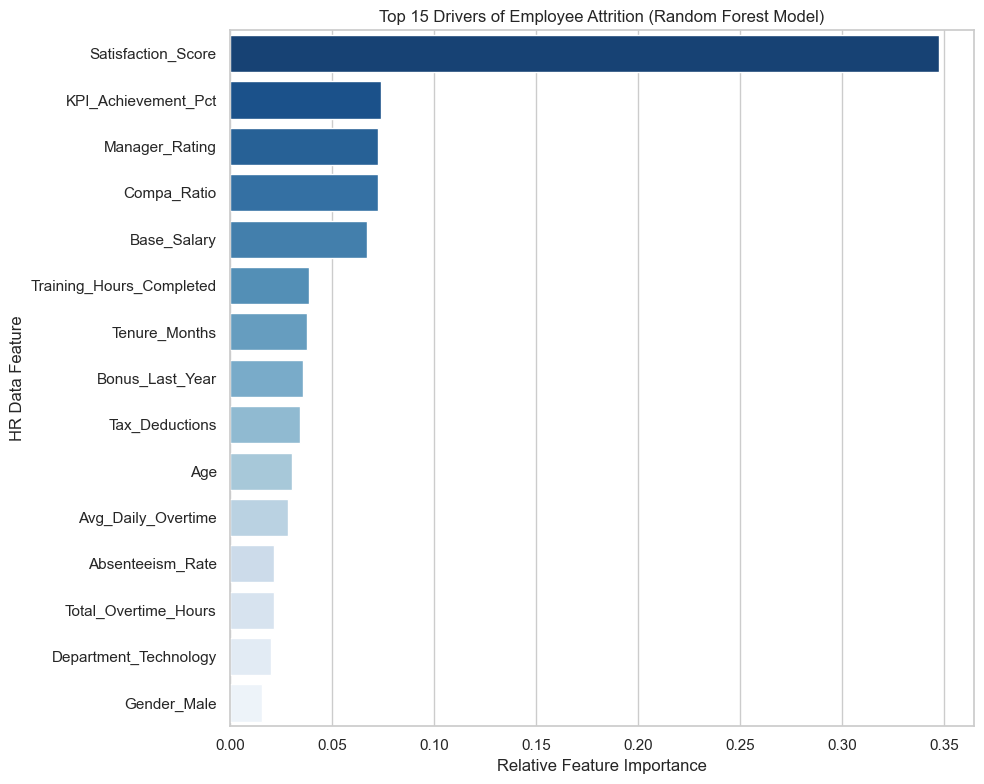

Top 5 Attrition Risk Factors Identified by Random Forest:
- Satisfaction_Score (Weight: 0.3474)
- KPI_Achievement_Pct (Weight: 0.0741)
- Manager_Rating (Weight: 0.0727)
- Compa_Ratio (Weight: 0.0727)
- Base_Salary (Weight: 0.0671)


In [13]:
# Extract feature importances from Random Forest
rf_importances = rf_model.feature_importances_

# Create DataFrame
rf_feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importances
})

# Sort by importance
rf_feature_importance_df = rf_feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display Top 15 Features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=rf_feature_importance_df.head(15),
    palette='Blues_r'
)

plt.title('Top 15 Drivers of Employee Attrition (Random Forest Model)')
plt.xlabel('Relative Feature Importance')
plt.ylabel('HR Data Feature')
plt.tight_layout()
plt.show()

# Print Top 5 Risk Factors
print("Top 5 Attrition Risk Factors Identified by Random Forest:")
for _, row in rf_feature_importance_df.head(5).iterrows():
    print(f"- {row['Feature']} (Weight: {row['Importance']:.4f})")

In [14]:
perm_result_xgb = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)
perm_result_rf = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)


comparison_df = pd.DataFrame({
    'Feature': X.columns,
    'RF_Feature_Importance': rf_model.feature_importances_,
    'XGB_Feature_Importance': xgb_model.feature_importances_,
    'RF_Permutation_Importance': perm_result_rf.importances_mean,
    'XGB_Permutation_Importance': perm_result_xgb.importances_mean
})

comparison_df = comparison_df.sort_values(
    by='XGB_Permutation_Importance',
    ascending=False
)

comparison_df.head(20)

,Feature,RF_Feature_Importance,XGB_Feature_Importance,RF_Permutation_Importance,XGB_Permutation_Importance
7,Satisfaction_Score,0.347436,0.411577,0.328884,0.331512
6,Manager_Rating,0.072744,0.156377,0.042528,0.120082
1,Base_Salary,0.067135,0.044228,-0.012532,0.025597
21,Department_Technology,0.020104,0.031754,-0.004904,0.016608
15,Compa_Ratio,0.072678,0.026229,-0.004106,0.009817
13,Tenure_Months,0.037749,0.018813,-0.001091,0.003403
18,Department_Marketing,0.006864,0.024031,-0.001840,0.002468
22,Gender_Male,0.015864,0.019496,0.011196,0.001788
14,Absenteeism_Rate,0.021532,0.000000,-0.002577,0.000000
23,Gender_Other,0.001219,0.000000,0.000000,0.000000


In [15]:
scaler = MinMaxScaler()

comparison_df.iloc[:, 1:] = scaler.fit_transform(
    comparison_df.iloc[:, 1:]
)

comparison_df = comparison_df.sort_values(
    by='XGB_Permutation_Importance',
    ascending=False
)

comparison_df.head(20)

,Feature,RF_Feature_Importance,XGB_Feature_Importance,RF_Permutation_Importance,XGB_Permutation_Importance
7,Satisfaction_Score,1.000000,1.000000,1.000000,1.000000
6,Manager_Rating,0.206590,0.379947,0.175490,0.402679
1,Base_Salary,0.190389,0.107459,0.016955,0.135744
21,Department_Technology,0.054545,0.077152,0.038917,0.110349
15,Compa_Ratio,0.206400,0.063729,0.041215,0.091163
13,Tenure_Months,0.105511,0.045710,0.049895,0.073043
18,Department_Marketing,0.016304,0.058388,0.047738,0.070401
22,Gender_Male,0.042300,0.047369,0.085273,0.068479
14,Absenteeism_Rate,0.058672,0.000000,0.045617,0.063429
23,Gender_Other,0.000000,0.000000,0.053037,0.063429


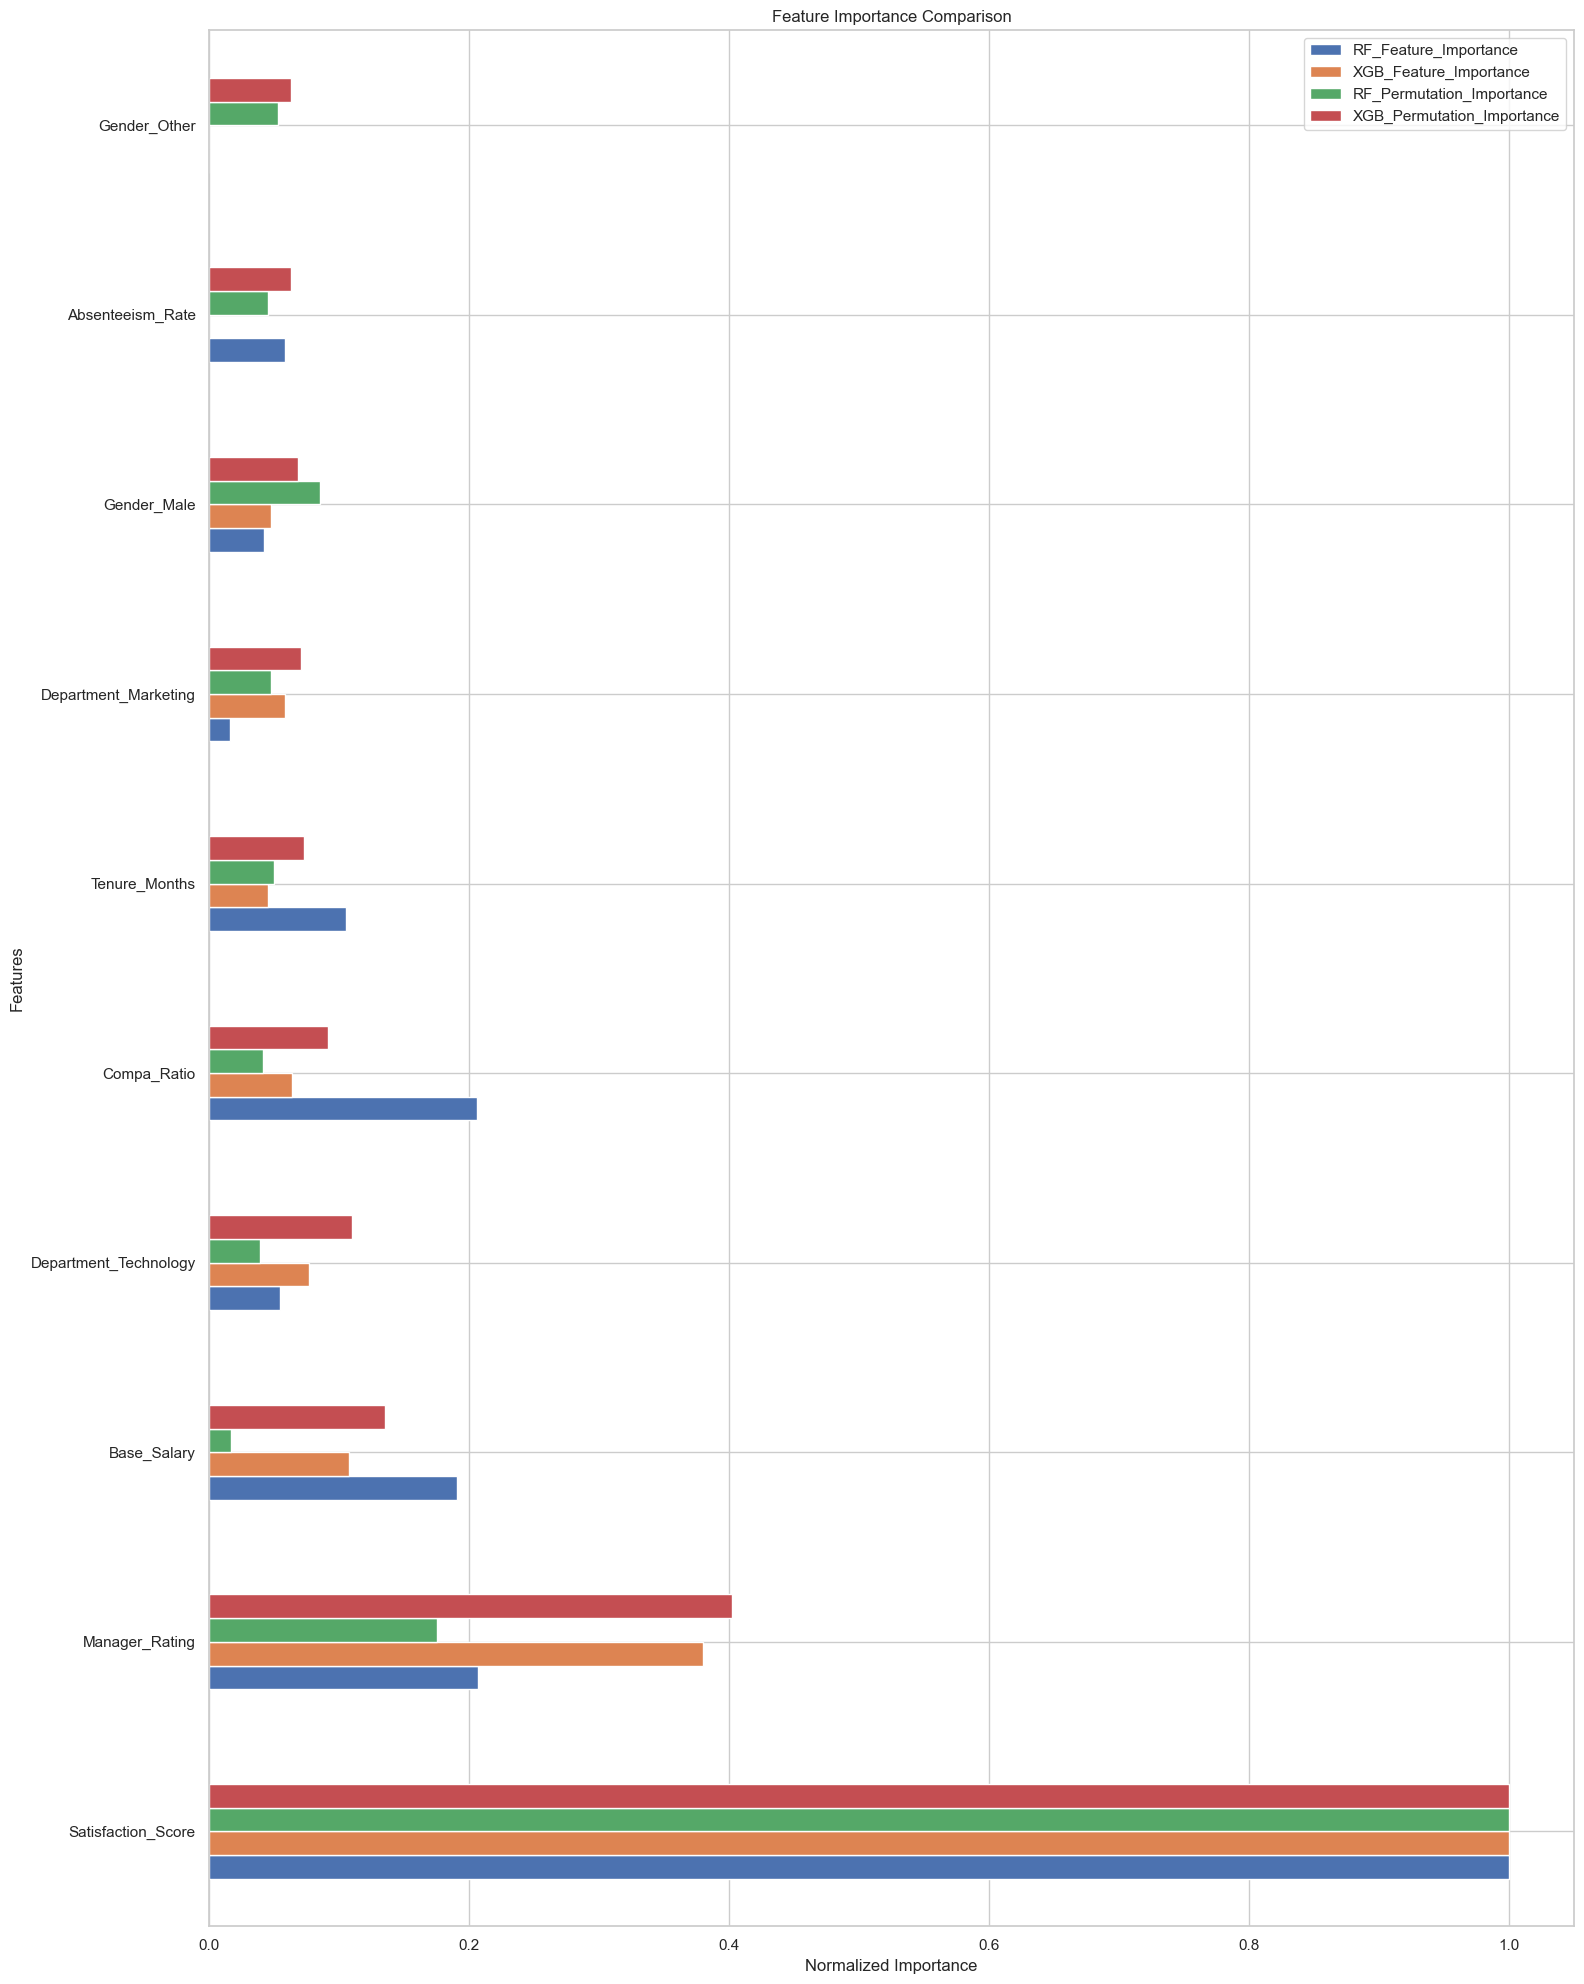

In [16]:
top_features = comparison_df.head(10)

top_features.set_index('Feature').plot(
    kind='barh',
    figsize=(16,20)
)

plt.title('Feature Importance Comparison')
plt.xlabel('Normalized Importance')
plt.ylabel('Features')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

---
## 5. Model 2: Performance Analysis & Forecasting (Regression/Multi-class)
For our second core model, we shift from predicting a binary outcome (Attrition) to forecasting a continuous productivity metric. By predicting an employee's future `KPI_Achievement_Pct`, HR can proactively identify workforce improvement areas and optimize training resources.

### 5.1 Defining Features and Target (y: KPI_Achievement_Pct)
We will treat this as a Regression task to predict the exact KPI score (ranging from 50 to 120). 

*Crucial Step:* We must drop `Manager_Rating` from our feature matrix (X). Because manager ratings are heavily based on KPI achievement, including it would cause "data leakage" (giving the model the answer key) and artificially inflate our results.

In [17]:
# Define the target variable (Continuous Regression Target)
y_perf = final_hr_df['KPI_Achievement_Pct']

# Define the feature matrix by dropping targets, identifiers, and leaky variables
X_perf = final_hr_df.drop(columns=['Employee_ID', 'KPI_Achievement_Pct', 'Manager_Rating'])

# Verify the shapes of X and y for the performance model
print(f"Performance Feature Matrix (X_perf) Shape: {X_perf.shape}")
print(f"Performance Target Vector (y_perf) Shape: {y_perf.shape}")

Performance Feature Matrix (X_perf) Shape: (2000, 23)
Performance Target Vector (y_perf) Shape: (2000,)


### 5.2 Train-Test Split
Just like the previous model, we perform an 80/20 train-test split. However, because our target is a continuous numerical value (regression) rather than distinct categories (classification), we do not need to use the `stratify` parameter here.

In [18]:
# Split the data into training and testing sets
X_train_perf, X_test_perf, y_train_perf, y_test_perf = train_test_split(
    X_perf, y_perf, 
    test_size=0.2, 
    random_state=42
)

# Display the dimensions of the split datasets
print(f"Training Features Shape (Performance Model): {X_train_perf.shape}")
print(f"Testing Features Shape (Performance Model): {X_test_perf.shape}")

Training Features Shape (Performance Model): (1600, 23)
Testing Features Shape (Performance Model): (400, 23)


### 5.3 Training Decision Tree Regressor
Since our target (`KPI_Achievement_Pct`) is a continuous numerical value ranging from 50 to 120, we will use a Decision Tree Regressor. Decision Trees are highly interpretable, meaning we can easily extract the exact logical paths (e.g., "If training hours > 20 and absenteeism < 5%, then KPI = 95%") to share with HR stakeholders.

In [19]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor
# Max depth is limited to 5 to prevent the model from overfitting on the training data
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)

# Fit the model on the performance training data
dt_regressor.fit(X_train_perf, y_train_perf)

# Generate predictions on the untouched test set
dt_predictions = dt_regressor.predict(X_test_perf)

print("Decision Tree Regressor successfully trained for KPI forecasting!")

Decision Tree Regressor successfully trained for KPI forecasting!


### 5.4 Training Logistic Regression (for binary high/low performance thresholds)
While predicting the exact KPI score is useful, HR often requires a simpler binary classification: *Will this employee be a Top Performer or require a Performance Improvement Plan (PIP)?* Here, we will convert our continuous KPI target into a binary classification (1 = High Performer, 0 = Average/Low Performer) using a threshold of 85%. Because Logistic Regression is sensitive to data scales, we must also apply a `StandardScaler` to our features first.

In [20]:
# Define the threshold for a "High Performer" (e.g., KPI >= 85)
kpi_threshold = 85

# Convert continuous targets to binary classes
y_train_class = (y_train_perf >= kpi_threshold).astype(int)
y_test_class = (y_test_perf >= kpi_threshold).astype(int)

# Initialize the StandardScaler (Logistic Regression requires scaled features)
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train_perf)
X_test_scaled = scaler.transform(X_test_perf)

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train_class)

# Generate binary predictions
log_reg_predictions = log_reg_model.predict(X_test_scaled)

print(f"Logistic Regression successfully trained to classify Top Performers (KPI >= {kpi_threshold})!")

Logistic Regression successfully trained to classify Top Performers (KPI >= 85)!


### 5.5 Model Evaluation & Productivity Trend Analysis
We need to evaluate both of our performance models. First, we will check the accuracy of our Decision Tree Regressor using Mean Squared Error (MSE) and R-squared. Then, we will evaluate our Logistic Regression classifier using standard classification metrics to see how well it identifies Top Performers.

--- Decision Tree Regressor Performance ---
Mean Squared Error (MSE): 27.04
R-squared (R2) Score: 0.9153

--- Logistic Regression (Top Performer) Performance ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        95
           1       0.97      0.98      0.98       305

    accuracy                           0.96       400
   macro avg       0.96      0.94      0.95       400
weighted avg       0.96      0.96      0.96       400



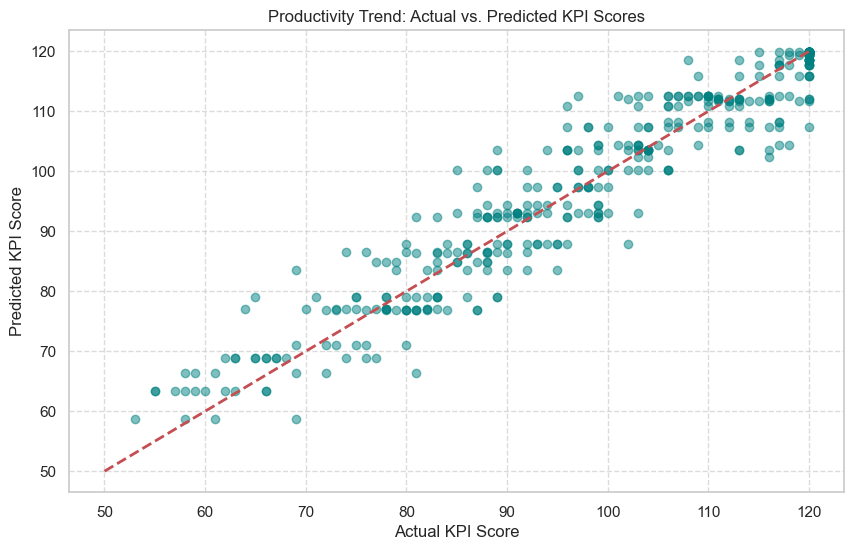

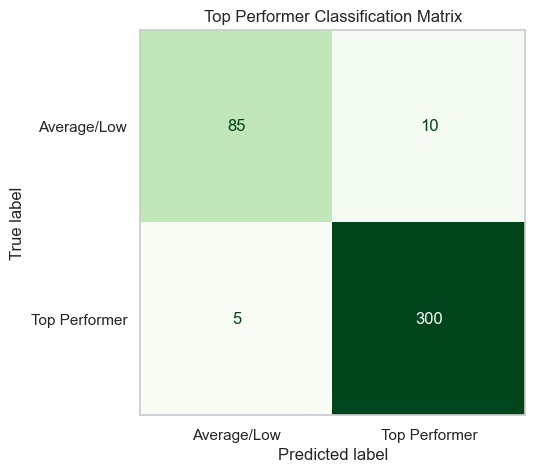

In [21]:
# --- Evaluate Decision Tree Regressor (Continuous KPI) ---
dt_mse = mean_squared_error(y_test_perf, dt_predictions)
dt_r2 = r2_score(y_test_perf, dt_predictions)

print("--- Decision Tree Regressor Performance ---")
print(f"Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"R-squared (R2) Score: {dt_r2:.4f}")

# --- Evaluate Logistic Regression (Binary Top Performer) ---
print("\n--- Logistic Regression (Top Performer) Performance ---")
print(classification_report(y_test_class, log_reg_predictions))

# --- Visualizing Productivity Trends (Actual vs Predicted) ---
plt.figure(figsize=(10, 6))
plt.scatter(y_test_perf, dt_predictions, alpha=0.5, color='teal')
plt.plot([50, 120], [50, 120], 'r--', lw=2) # Perfect prediction line
plt.title('Productivity Trend: Actual vs. Predicted KPI Scores')
plt.xlabel('Actual KPI Score')
plt.ylabel('Predicted KPI Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Visualizing Logistic Regression Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_class, log_reg_predictions, 
    ax=ax, cmap='Greens', colorbar=False,
    display_labels=['Average/Low', 'Top Performer']
)
ax.set_title('Top Performer Classification Matrix')
ax.grid(False)
plt.show()

### 5.6 Identifying Key Drivers for Performance Improvement
To provide actionable recommendations to HR, we need to understand *what* drives high performance. By extracting the coefficients from our Logistic Regression model, we can see which features positively impact the probability of being a Top Performer (e.g., Training Hours) and which features drag performance down (e.g., Absenteeism, Overtime).

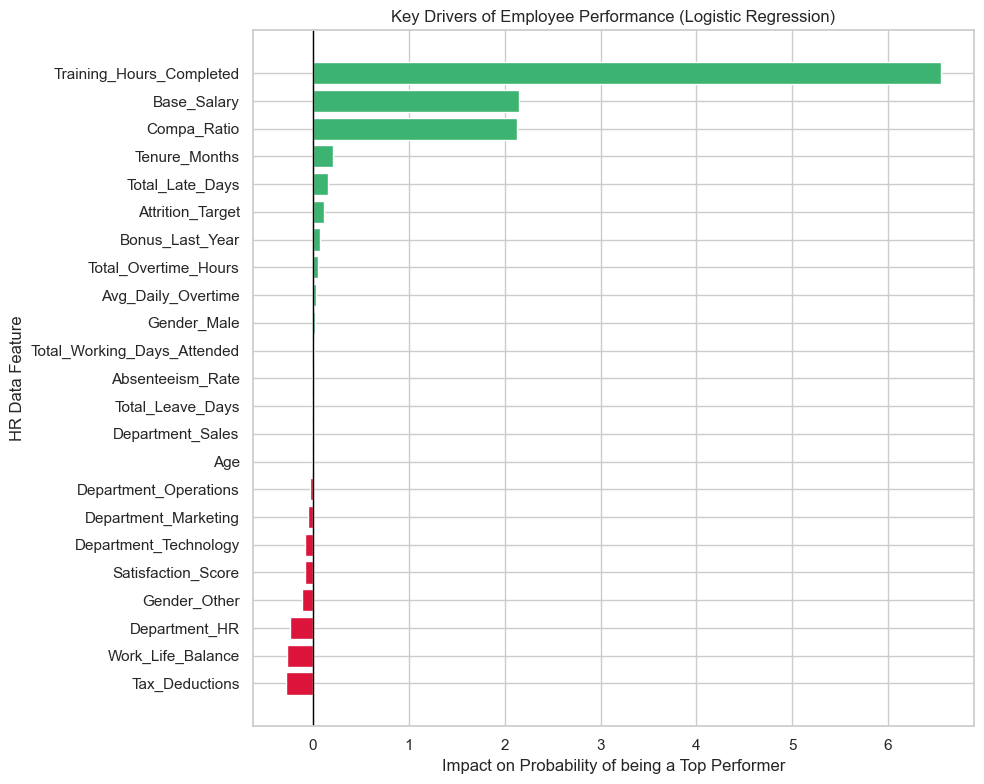

Top 3 Positive Drivers for Performance Improvement:
                 Feature  Impact_Coefficient
Training_Hours_Completed            6.554481
             Base_Salary            2.147039
             Compa_Ratio            2.129695

Top 3 Negative Drivers (Performance Blockers):
          Feature  Impact_Coefficient
   Tax_Deductions           -0.285119
Work_Life_Balance           -0.275762
    Department_HR           -0.235807


In [22]:
# Extract coefficients from the Logistic Regression model
log_reg_coefs = log_reg_model.coef_[0]

# Create a DataFrame to map features to their coefficients
performance_drivers_df = pd.DataFrame({
    'Feature': X_perf.columns,
    'Impact_Coefficient': log_reg_coefs
})

# Sort by impact (positive to negative)
performance_drivers_df = performance_drivers_df.sort_values(by='Impact_Coefficient', ascending=True)

# Separate into positive and negative drivers for color coding
colors = ['crimson' if x < 0 else 'mediumseagreen' for x in performance_drivers_df['Impact_Coefficient']]

# Plot the Key Performance Drivers
plt.figure(figsize=(10, 8))
plt.barh(performance_drivers_df['Feature'], performance_drivers_df['Impact_Coefficient'], color=colors)

plt.title('Key Drivers of Employee Performance (Logistic Regression)')
plt.xlabel('Impact on Probability of being a Top Performer')
plt.ylabel('HR Data Feature')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

# Print textual summary for HR
print("Top 3 Positive Drivers for Performance Improvement:")
print(performance_drivers_df.tail(3).sort_values(by='Impact_Coefficient', ascending=False).to_string(index=False))

print("\nTop 3 Negative Drivers (Performance Blockers):")
print(performance_drivers_df.head(3).to_string(index=False))

---
## 6. Model 3: Attendance & Workforce Analysis (Anomaly Detection)
In this final model, we shift to Unsupervised Learning. Our goal is to detect irregular attendance patterns (like chronic lateness, extreme overtime, or potential buddy punching). Because we do not have labeled "anomalies" in our dataset, we will use an algorithm to find the outliers automatically.

### 6.1 Selecting Time, Attendance, and Leave Features
We will isolate only the features related to time and attendance. Furthermore, distance-based anomaly detection models require all features to be on the same scale, so we will apply a `StandardScaler` to this subset of data before feeding it to the algorithm.

In [23]:
# Select features specifically related to attendance and working hours
attendance_features = [
    'Total_Overtime_Hours', 
    'Total_Late_Days', 
    'Absenteeism_Rate', 
    'Avg_Daily_Overtime'
]

# Create the feature matrix for the anomaly detection model
X_attendance = final_hr_df[attendance_features]

# Initialize scaler and transform the data
# Scaling is critical so 'Total_Overtime_Hours' (large numbers) doesn't overshadow 'Absenteeism_Rate' (decimals)
scaler_att = StandardScaler()
X_attendance_scaled = scaler_att.fit_transform(X_attendance)

# Display the shape to confirm
print(f"Attendance Feature Matrix Shape: {X_attendance_scaled.shape}")

Attendance Feature Matrix Shape: (2000, 4)


### 6.2 Model Selection for Anomaly Detection (Isolation Forest)
We will use the **Isolation Forest** algorithm. Instead of trying to profile normal behavior, this algorithm explicitly isolates anomalies by building random decision trees. Anomalies (outliers) are easier to isolate, meaning they end up closer to the root of the tree with shorter path lengths. 

We will configure the model to flag the top 5% most unusual attendance patterns in the company.

In [24]:
# Initialize the Isolation Forest model
# contamination=0.05 tells the model to flag the most extreme 5% of the data as anomalies
iso_forest = IsolationForest(
    n_estimators=100, 
    contamination=0.05, 
    random_state=42, 
    n_jobs=-1
)

# Fit the model on the scaled attendance data
iso_forest.fit(X_attendance_scaled)

# Generate predictions (-1 indicates an anomaly, 1 indicates normal behavior)
anomaly_predictions = iso_forest.predict(X_attendance_scaled)

# Add the predictions back to our main dataset for review
final_hr_df['Attendance_Anomaly_Flag'] = anomaly_predictions

# Map the -1/1 output to a readable string format
final_hr_df['Attendance_Status'] = final_hr_df['Attendance_Anomaly_Flag'].map({1: 'Normal', -1: 'Anomaly'})

print("Isolation Forest successfully trained and anomalies flagged!")

Isolation Forest successfully trained and anomalies flagged!


### 6.3 Analyzing the Detected Irregular Patterns (Buddy Punching, Chronic Absenteeism)
Since we trained the Isolation Forest and generated predictions in the previous step, we now need to profile these anomalies. By comparing the averages of "Normal" employees against "Anomalous" employees, we can see exactly *why* the AI flagged them (e.g., discovering clusters of extreme overtime indicating burnout, or high late days indicating chronic absenteeism).

Total Irregular Patterns Detected: 100 employees

--- Behavioral Profile Comparison ---
                   Total_Overtime_Hours  Total_Late_Days  Absenteeism_Rate  \
Attendance_Status                                                            
Anomaly                           22.16             2.18              0.02   
Normal                            22.21             1.38              0.01   

                   Avg_Daily_Overtime  
Attendance_Status                      
Anomaly                          0.35  
Normal                           0.35  


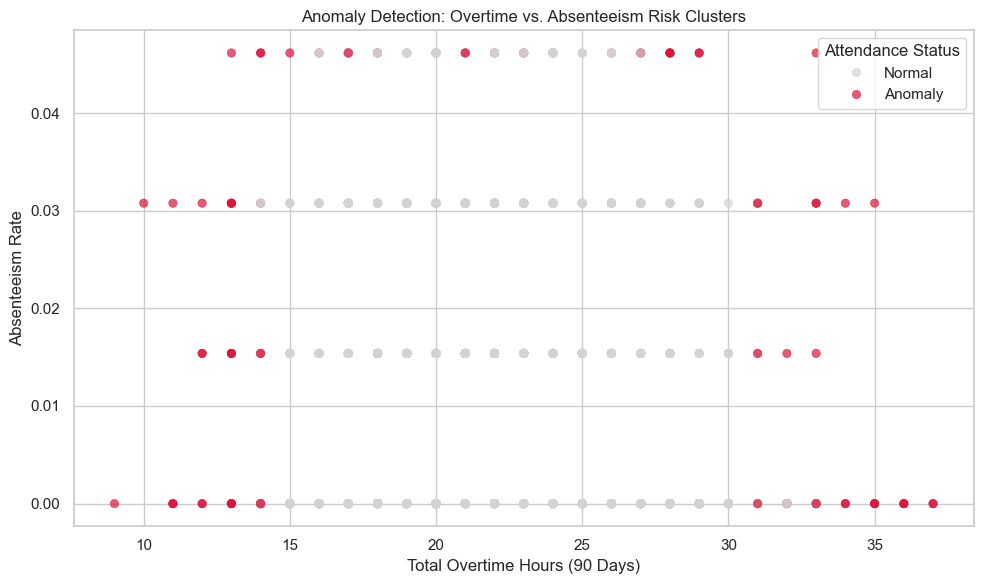

In [25]:
# Isolate the anomalous records for inspection
anomalies_df = final_hr_df[final_hr_df['Attendance_Status'] == 'Anomaly']
print(f"Total Irregular Patterns Detected: {len(anomalies_df)} employees")

# Compare average metrics between Normal and Anomalous employees
profile_comparison = final_hr_df.groupby('Attendance_Status')[attendance_features].mean().round(2)
print("\n--- Behavioral Profile Comparison ---")
print(profile_comparison)

# Visualize the anomalies (Overtime vs. Absenteeism)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_hr_df,
    x='Total_Overtime_Hours',
    y='Absenteeism_Rate',
    hue='Attendance_Status',
    palette={'Normal': 'lightgray', 'Anomaly': 'crimson'},
    alpha=0.7,
    edgecolor=None
)

plt.title('Anomaly Detection: Overtime vs. Absenteeism Risk Clusters')
plt.xlabel('Total Overtime Hours (90 Days)')
plt.ylabel('Absenteeism Rate')
plt.legend(title='Attendance Status')
plt.tight_layout()
plt.show()

### 6.4 Workforce Utilization & Risk Flagging
Anomalies at the individual level are useful for managers, but HR needs a macro-level view of workforce utilization. Here, we aggregate the anomaly flags by department to identify structural risks—such as a specific department suffering from systemic burnout (over-utilization) or high absenteeism (under-utilization).

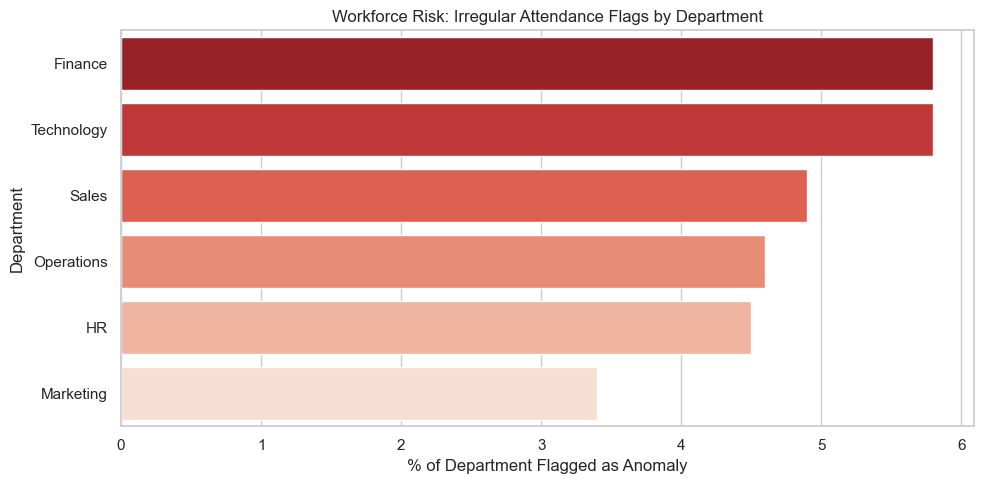

--- Departmental Workforce Utilization Risk Report ---


,Department,Total_Employees,Anomalies_Detected,Risk_Percentage
0,Finance,207,12,5.8
5,Technology,571,33,5.8
4,Sales,390,19,4.9
3,Operations,518,24,4.6
1,HR,111,5,4.5
2,Marketing,203,7,3.4



CRITICAL ALERT: Identified 36 employees who exhibit BOTH irregular attendance patterns AND a high probability of imminent attrition.


In [30]:
# --- 6.4 Workforce Utilization & Risk Flagging ---
master_df=pd.read_csv(RAW_DIR+'/1_Employee_Master.csv')

# Trick: Re-attach the original 'Department' column from master_df (which is still in memory)
final_hr_df = final_hr_df.merge(master_df[['Employee_ID', 'Department']], on='Employee_ID', how='left')

# Calculate Workforce Risk by Department
dept_risk_summary = final_hr_df.groupby('Department').agg(
    Total_Employees=('Employee_ID', 'count'),
    Anomalies_Detected=('Attendance_Anomaly_Flag', lambda x: (x == -1).sum())
).reset_index()

# Calculate the percentage of the department flagged as a risk
dept_risk_summary['Risk_Percentage'] = (dept_risk_summary['Anomalies_Detected'] / dept_risk_summary['Total_Employees'] * 100).round(1)

# Sort to highlight the highest risk departments first
dept_risk_summary = dept_risk_summary.sort_values(by='Risk_Percentage', ascending=False)

# Plot the departmental risk summary
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(
    data=dept_risk_summary, 
    x='Risk_Percentage', 
    y='Department', 
    palette='Reds_r'
)

plt.title('Workforce Risk: Irregular Attendance Flags by Department')
plt.xlabel('% of Department Flagged as Anomaly')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

# Print the final risk flagging report for HR
print("--- Departmental Workforce Utilization Risk Report ---")
display(dept_risk_summary)

# Create a "Critical Flight Risk" flag: Employee is an Anomaly AND predicted to leave
final_hr_df['Critical_Flight_Risk'] = ((final_hr_df['Attendance_Status'] == 'Anomaly') & (final_hr_df['Attrition_Target'] == 1)).astype(int)
critical_count = final_hr_df['Critical_Flight_Risk'].sum()

print(f"\nCRITICAL ALERT: Identified {critical_count} employees who exhibit BOTH irregular attendance patterns AND a high probability of imminent attrition.")

---
## 7. Deliverables & Outputs Generation
In this final phase of Day 2, we serialize our trained machine learning models, save our data preprocessing pipeline objects (like the scalers), and export our comprehensive prediction results so they can be integrated into the Day 4 Dashboard.

### 7.1 Saving Trained Models (using joblib)
We use the `joblib` library because it is highly optimized for saving scikit-learn and XGBoost models that contain large internal NumPy arrays. Saving these models allows us to load them directly into our application later without having to retrain them every time.

In [31]:
import joblib
import os

# Define the directory for saving models
MODEL_DIR = r'D:\OFFICE\Tasks\AI_based_HR_system\models\\'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save Model 1: Attrition Classification
joblib.dump(xgb_model, MODEL_DIR + 'xgboost_attrition_model.pkl')
joblib.dump(rf_model, MODEL_DIR + 'random_forest_attrition_model.pkl')

# Save Model 2: Performance Forecasting
joblib.dump(dt_regressor, MODEL_DIR + 'decision_tree_kpi_model.pkl')
joblib.dump(log_reg_model, MODEL_DIR + 'logistic_regression_top_performer_model.pkl')

# Save Model 3: Attendance Anomaly Detection
joblib.dump(iso_forest, MODEL_DIR + 'isolation_forest_attendance_model.pkl')

# Save Preprocessing Objects (Crucial for scoring new data later)
joblib.dump(scaler, MODEL_DIR + 'standard_scaler_performance.pkl')
joblib.dump(scaler_att, MODEL_DIR + 'standard_scaler_attendance.pkl')

print(f"Successfully saved 5 machine learning models and 2 scalers to {MODEL_DIR}")

Successfully saved 5 machine learning models and 2 scalers to D:\OFFICE\Tasks\AI_based_HR_system\models\\


### 7.2 Exporting Processed Pipeline Data to CSV
We need to export the `final_hr_df` (which contains all our engineered features, imputations, and anomaly flags). This serves as the single source of truth for the upcoming AI Analytics & Recommendation Engine (Day 3).

In [32]:
# Define the directory for processed data
PROCESSED_DIR = r'D:\OFFICE\Tasks\AI_based_HR_system\data\processed\\'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Export the master processed dataset
final_hr_df.to_csv(PROCESSED_DIR + 'final_hr_dataset_processed.csv', index=False)

print(f"Successfully exported the processed master dataset to {PROCESSED_DIR}")

Successfully exported the processed master dataset to D:\OFFICE\Tasks\AI_based_HR_system\data\processed\\


### 7.3 Exporting Initial Prediction Outputs (Attrition Risks & Anomalies) to CSV
Instead of handing HR a raw data dump, we create a specialized, clean report containing just the actionable AI insights for every employee in the company. We generate these predictions across the entire feature matrix (`X` and `X_perf`), not just the 20% test set.

In [33]:
# Create a clean DataFrame specifically for HR stakeholders
hr_insights_report = master_df[['Employee_ID', 'Department']].copy()

# Add Model 1 Predictions (Attrition Risk)
# We provide the exact probability percentage alongside the binary flag
hr_insights_report['Attrition_Probability'] = xgb_model.predict_proba(X)[:, 1].round(3)
hr_insights_report['Predicted_Attrition_Flag'] = xgb_model.predict(X)

# Add Model 2 Predictions (Performance Forecasting)
hr_insights_report['Forecasted_KPI_Score'] = dt_regressor.predict(X_perf).round(1)
hr_insights_report['Predicted_Top_Performer'] = log_reg_model.predict(scaler.transform(X_perf))

# Add Model 3 Predictions (Attendance Anomalies & Critical Risks)
hr_insights_report['Attendance_Status'] = final_hr_df['Attendance_Status']
hr_insights_report['Critical_Flight_Risk'] = final_hr_df['Critical_Flight_Risk']

# Sort the report to bring high-risk employees to the top
hr_insights_report = hr_insights_report.sort_values(
    by=['Critical_Flight_Risk', 'Attrition_Probability'], 
    ascending=[False, False]
)

# Export the final predictions report
hr_insights_report.to_csv(PROCESSED_DIR + 'hr_predictive_insights_report.csv', index=False)

print("Successfully exported the HR Predictive Insights Report to CSV!")

# Display the top 5 most actionable rows for HR
display(hr_insights_report.head())

Successfully exported the HR Predictive Insights Report to CSV!


,Employee_ID,Department,Attrition_Probability,Predicted_Attrition_Flag,Forecasted_KPI_Score,Predicted_Top_Performer,Attendance_Status,Critical_Flight_Risk
949,EMP00950,Technology,0.995,1,68.8,0,Anomaly,1
561,EMP00562,HR,0.992,1,79.1,0,Anomaly,1
1503,EMP01504,Operations,0.992,1,63.3,0,Anomaly,1
667,EMP00668,Sales,0.990,1,71.1,0,Anomaly,1
19,EMP00020,HR,0.989,1,77.0,0,Anomaly,1
